In [1]:
# ============================================================
# Tugas 3 - Fuzzy Inteference System
# Kelas: Kecerdasan Buatan
# Dosen: Muhammad Qomaruz Zaman, S.T., M.T., Ph.D.
# NAMA : Prayudhisti Basuki
# NRP  : 6022251075
# ============================================================

# ============================================================
# FUZZY INFERENCE SYSTEM (FIS) SUGENO ORDE-0
# PENENTUAN HARGA PAKET PENJUALAN PV
# ============================================================


import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINISI FUNGSI KEANGGOTAAN (MEMBERSHIP FUNCTIONS) ---

def triangle(x, a, b, c, d, e):
    """
    Calculates the membership value for a triangular fuzzy function using if/elif/else.

    Parameters:
    x (float or np.array): The input value(s).
    a (float): The left-most X point, paired with y value d.
    b (float): The middle X point, paired with Y value of 1.
    c (float): The right-most X point, paired with Y value e.
    d (float): The y-value at point a.
    e (float): The y-value at point c.

    Returns:
    float or np.array: The membership value(s).
    """

    if x < a:
        return d
    elif a <= x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return (c - x) / (c - b)
    elif x > c:
        return e
    else:
        return 0

# --- 2. ENGINE FUZZY INFERENCE SYSTEM ---

def hitung_fis_sugeno(input_luas, input_daya):
    # Fuzzifikasi Input 1: Luas (0 - 100 m2)
    mu_luas = {
        'sedikit': triangle(input_luas, 25, 25, 50, 1, 0 ),
        'sedang' : triangle(input_luas, 25, 50, 75, 0, 0),
        'banyak' : triangle(input_luas, 50, 75, 100, 0, 1)
    }

    # Fuzzifikasi Input 2: Daya (0 - 10 kWp)
    mu_daya = {
        'kecil'   : triangle(input_daya, 2, 2, 5, 1, 0),
        'menengah': triangle(input_daya, 2, 5, 8, 0, 0),
        'besar'   : triangle(input_daya, 5, 8, 10, 0, 1)
    }

    # Output Sugeno Orde-0 (Singleton dalam Juta Rp)
    Z = {'basic': 10, 'premium': 25, 'platinum': 45}

    # Aturan Fuzzy (Total 9 Aturan)
    # Format: (Luas, Daya, Output_Z)
    rules = [
        (mu_luas['sedikit'], mu_daya['kecil'],    Z['basic']),
        (mu_luas['sedikit'], mu_daya['menengah'], Z['basic']),
        (mu_luas['sedikit'], mu_daya['besar'],    Z['premium']), # Rule Contoh
        (mu_luas['sedang'],  mu_daya['kecil'],    Z['basic']),
        (mu_luas['sedang'],  mu_daya['menengah'], Z['premium']),
        (mu_luas['sedang'],  mu_daya['besar'],    Z['platinum']),
        (mu_luas['banyak'],  mu_daya['kecil'],    Z['premium']),
        (mu_luas['banyak'],  mu_daya['menengah'], Z['platinum']),
        (mu_luas['banyak'],  mu_daya['besar'],    Z['platinum'])
    ]

    # Inferensi & Defuzzifikasi (Weighted Average)
    numerator = 0
    denominator = 0

    for i, (m1, m2, z_val) in enumerate(rules):
        w = min(m1, m2)  # Operator AND (Mencari nilai minimum)
        if w > 0:
            numerator += w * z_val
            denominator += w

    if denominator == 0:
        return 0

    return numerator / denominator

# --- 3. EKSEKUSI DAN VISUALISASI ---

# Get user input
user_luas = float(input("Masukkan Luas PV : "))
user_daya = float(input("Masukkan Daya PV : "))

harga_akhir = hitung_fis_sugeno(user_luas, user_daya)

print("-" * 30)
print(f"HASIL PERHITUNGAN SIMULASI")
print(f"Input Luas: {user_luas} m2 | Input Daya: {user_daya} kWp")
print(" ")
print("Detail Aktivasi Aturan:")

# Re-fuzzify inputs to get membership degrees for printing details
mu_luas_print = {
        'sedikit': triangle(user_luas, 25, 25, 50, 1, 0 ),
        'sedang' : triangle(user_luas, 25, 50, 75, 0, 0),
        'banyak' : triangle(user_luas, 50, 75, 100, 0, 1)
}

mu_daya_print = {
        'kecil'   : triangle(user_daya, 2, 2, 5, 1, 0),
        'menengah': triangle(user_daya, 2, 5, 8, 0, 0),
        'besar'   : triangle(user_daya, 5, 8, 10, 0, 1)
}

# Output Sugeno Orde-0 (Singleton dalam Juta Rp)
Z_print = {'basic': 10, 'premium': 25, 'platinum': 45}

rules_print = [
    (mu_luas_print['sedikit'], mu_daya_print['kecil'],    Z_print['basic']),
    (mu_luas_print['sedikit'], mu_daya_print['menengah'], Z_print['basic']),
    (mu_luas_print['sedikit'], mu_daya_print['besar'],    Z_print['premium']),
    (mu_luas_print['sedang'],  mu_daya_print['kecil'],    Z_print['basic']),
    (mu_luas_print['sedang'],  mu_daya_print['menengah'], Z_print['premium']),
    (mu_luas_print['sedang'],  mu_daya_print['besar'],    Z_print['platinum']),
    (mu_luas_print['banyak'],  mu_daya_print['kecil'],    Z_print['premium']),
    (mu_luas_print['banyak'],  mu_daya_print['menengah'], Z_print['platinum']),
    (mu_luas_print['banyak'],  mu_daya_print['besar'],    Z_print['platinum'])
]

for i, (m1, m2, z_val) in enumerate(rules_print):
    w = min(m1, m2)  # Operator AND (Mencari nilai minimum)
    if w > 0:
        print(f" - R{i+1} aktif dengan bobot (w): {w:.2f}, Nilai Z: {z_val}")

# Determine the 'Jenis Paket' based on the output price
jenis_paket_str = ""
if harga_akhir == 10.0:
    jenis_paket_str = "Basic"
elif harga_akhir == 25.0:
    jenis_paket_str = "Premium"
elif harga_akhir == 45.0:
    jenis_paket_str = "Platinum"
else:
    jenis_paket_str = f"Custom (Value: {harga_akhir:.2f})"

print(f"Jenis Paket: {jenis_paket_str}")
print("-" * 30)



Masukkan Luas PV : 12
Masukkan Daya PV : 5
------------------------------
HASIL PERHITUNGAN SIMULASI
Input Luas: 12.0 m2 | Input Daya: 5.0 kWp
 
Detail Aktivasi Aturan:
 - R2 aktif dengan bobot (w): 1.00, Nilai Z: 10
Jenis Paket: Basic
------------------------------


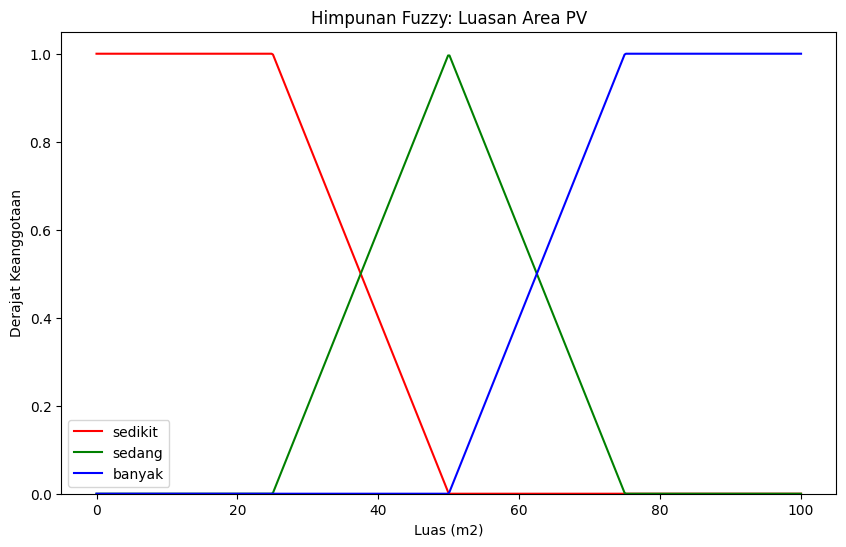

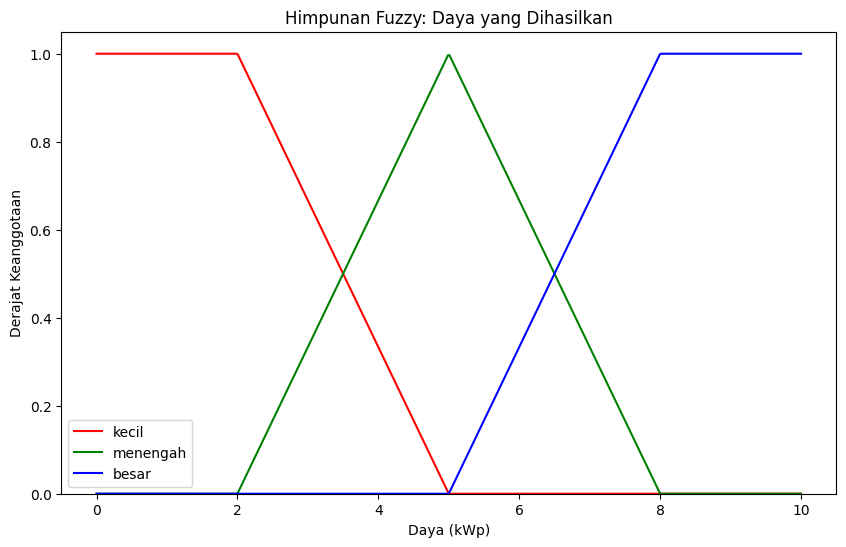

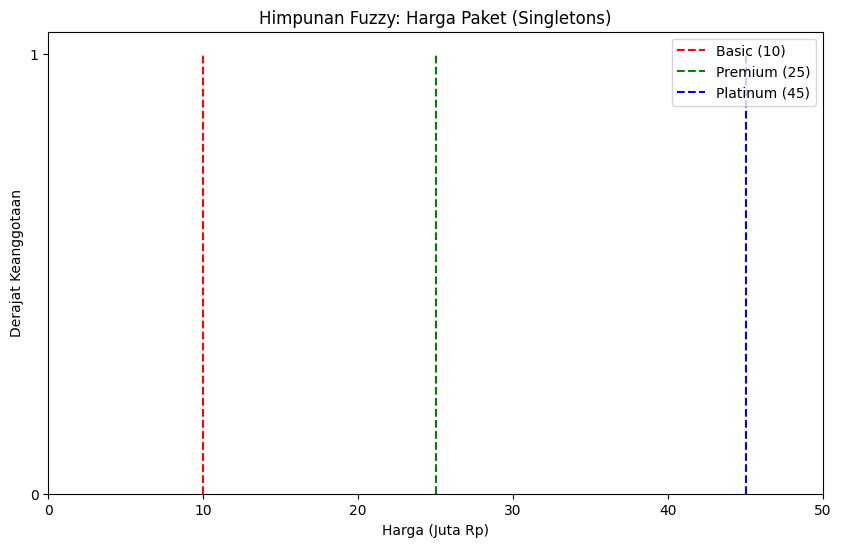

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Define universes
x_luas = np.linspace(0, 100, 500)
x_daya = np.linspace(0, 10, 500)
x_harga = np.linspace(0, 50, 500)

# --- Plot Luas Membership Functions ---
plt.figure(figsize=(10, 6))
plt.plot(x_luas, [triangle(x, 25, 25, 50, 1, 0 ) for x in x_luas], label='sedikit', color='red')
plt.plot(x_luas, [triangle(x, 25, 50, 75, 0, 0) for x in x_luas], label='sedang', color='green')
plt.plot(x_luas, [triangle(x, 50, 75, 75, 0, 1) for x in x_luas], label='banyak', color='blue')
plt.title('Himpunan Fuzzy: Luasan Area PV')
plt.xlabel('Luas (m2)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(False)
plt.ylim(0, 1.05)
plt.show()

# --- Plot Daya Membership Functions ---
plt.figure(figsize=(10, 6))
plt.plot(x_daya, [triangle(x, 2, 2, 5, 1, 0) for x in x_daya], label='kecil', color='red')
plt.plot(x_daya, [triangle(x, 2, 5, 8, 0, 0) for x in x_daya], label='menengah', color='green')
plt.plot(x_daya, [triangle(x, 5, 8, 8, 0, 1) for x in x_daya], label='besar', color='blue')
plt.title('Himpunan Fuzzy: Daya yang Dihasilkan')
plt.xlabel('Daya (kWp)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(False)
plt.ylim(0, 1.05)
plt.show()

# --- Plot Harga (Output) Membership Functions (Singletons) ---
plt.figure(figsize=(10, 6))
# For singletons, we can use vlines or just plot points to represent their value at degree 1
plt.vlines(10, 0, 1, linestyles='dashed', colors='red', label='Basic (10)')
plt.vlines(25, 0, 1, linestyles='dashed', colors='green', label='Premium (25)')
plt.vlines(45, 0, 1, linestyles='dashed', colors='blue', label='Platinum (45)')

plt.title('Himpunan Fuzzy: Harga Paket (Singletons)')
plt.xlabel('Harga (Juta Rp)')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(False)
plt.xlim(0, 50)
plt.ylim(0, 1.05) # Ensure y-axis shows 0 to 1 for membership degree
plt.yticks([0, 1]) # Only show 0 and 1 for singleton membership
plt.show()

In [34]:
# List skenario (Luas, Daya)
skenario_uji = [
    (10, 1), (25, 3), (35, 9), (45, 4), (50, 5),
    (55, 6), (65, 3), (75, 8), (90, 9), (100, 10)
]

print(f"{'No':<4} | {'Luas':<6} | {'Daya':<6} | {'Harga Estimasi (Juta)':<20}")
print("-" * 50)

for i, (l, d) in enumerate(skenario_uji, 1):
    harga_hasil = fis.hitung_harga(l, d) # Menggunakan class FIS_SolarPanel sebelumnya
    print(f"{i:<4} | {l:<6} | {d:<6} | Rp {harga_hasil:>18.2f}")

No   | Luas   | Daya   | Harga Estimasi (Juta)
--------------------------------------------------
1    | 10     | 1      | Rp              10.00
2    | 25     | 3      | Rp              10.00
3    | 35     | 9      | Rp              35.00
4    | 45     | 4      | Rp              25.00
5    | 50     | 5      | Rp              25.00
6    | 55     | 6      | Rp              25.00
7    | 65     | 3      | Rp              17.50
8    | 75     | 8      | Rp              45.00
9    | 90     | 9      | Rp              45.00
10   | 100    | 10     | Rp              10.00
